# Chapter 10 - Adaptive filtering

*This notebook contains all the sample code in Chapter 10.*

## Outline

- [System identification](#Identification)
- [The Least Mean Squares (LMS) algorithm](#LMS)
    - [Variants of the LMS algorithm](#Variants)
- [Affine Projection Algorithm](#APA)
- [Recursive Least Squares](#RLS)

## System identification <a id="Identification"></a>

**System identification** aims to estimate the parameters $\boldsymbol{\theta} \in \mathbb{R}^M$ of an unknown system from observations of its input $x[n]$ and output $d[n]$ sequences. We assume that the unknown system is *linear* and that the output measurements are corrupted by *additive noise*. Therefore, the observed output is modeled as:
$$
d[n] = \boldsymbol{\theta}^\top \mathbf{x}_n + v[n],
$$
is the regression vector containing the most recent $M$ input samples, and $v[n]$ is a zero-mean noise signal with variance $\sigma_v^2$.

To estimate the unknown parameter vector $\boldsymbol{\theta}$, we use a linear **adaptive filter** with coefficient vector $\mathbf{w}_n$. At each time instant, the coefficients are updated according to a rule designed to minimize a *cost function* that measures the discrepancy between the output of the unknown system and that of the adaptive model.

At time $n$, the discrepancy between the desired output $d[n]$ and the adaptive-filter output $y[n]$ is measured by the *error*:
$$
e[n] = d[n] - y[n].
$$
For a linear finite impulse response filter, the output is evaluated as:
$$
y[n] = \sum_{k=0}^{M-1} w_n[k]x[n-k]
     = \mathbf{w}_n^\top \mathbf{x}_n,
$$
where $\mathbf{w}_n = \big[w_n[0], w_n[1], \ldots, w_n[M-1]\big]^\top$ contains the $M$ adaptive-filter coefficients available at time $n$. 

The objective is to update $\mathbf{w}_n$ so that it approaches the unknown vector $\boldsymbol{\theta}$ and produces a small prediction error.

## The Least Mean Squares (LMS) algorithm <a id="LMS"></a>

The **Least Mean Squares** (LMS) algorithm is one of the simplest and most widely used adaptive filtering methods. It can be interpreted as an online stochastic-gradient algorithm. At time $n$, the filter computes the output and error using $\mathbf{w}_n$ and then updates the coefficients according to:
$$
\mathbf{w}_{n+1}
= \mathbf{w}_n - \mu \nabla_{\mathbf{w}} \widehat{\mathcal{L}}_n(\mathbf{w})\big|_{\mathbf{w}=\mathbf{w}_n},
$$
where $\mu>0$ is the **step size**, also called the **learning rate*. It controls the magnitude of each coefficient update.

Computing the gradient gives the **LMS update**:
$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu e[n]\mathbf{x}_n.
$$

A function implementing this recursion is:

In [1]:
import numpy as np

def lms(x, d, mu, M):
    L = len(x)
    e = np.zeros(L)      # Error signal
    y = np.zeros(L)      # Filter output
    w = np.zeros(M)      # Coefficient vector
    x_vec = np.zeros(M)  # Input delay line

    for n in range(L):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]

        y[n] = w @ x_vec
        e[n] = d[n] - y[n]
        w += mu * e[n] * x_vec

    return y, e

The function can be used to identify an unknown system with coefficient vector `w0`. To obtain a smooth estimate of the learning curve, the experiment can be repeated using independent input and noise realizations, and the squared error can then be averaged across trials:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

Text(0, 0.5, 'MSE [dB]')

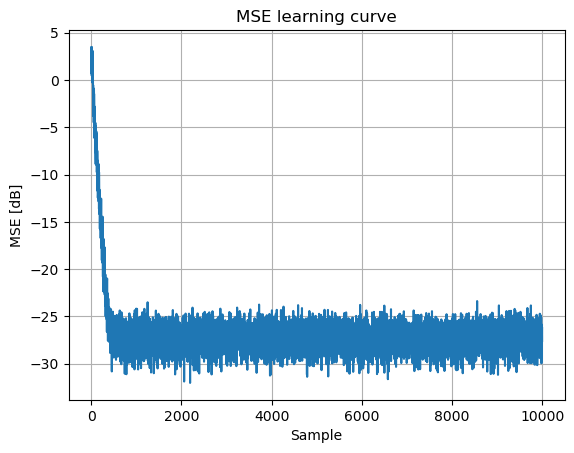

In [2]:
from scipy import signal as sp
import matplotlib.pyplot as plt

N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
mu = 0.01

e_avg = np.zeros(N)

for _ in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    y, e = lms(x, d, mu, M)
    e_avg += e**2

MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot MSE
plt.figure()
plt.plot(MSE)
plt.grid()
plt.title("MSE learning curve")
plt.xlabel("Sample")
plt.ylabel("MSE [dB]")

For reuse in larger programs, it is convenient to implement the LMS algorithm as a class. The class should provide at least an `update()` method for online adaptation and a `predict()` method for filtering new input data with the learned coefficients.

Following the convention adopted by Scikit-learn, which is introduced in the next chapter, attributes estimated from data rather than supplied directly by the user are given names ending with an underscore, such as `w_`.

In [3]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt

class LMS:

    def __init__(self, M, mu=0.01):
        self.M = M
        self.mu = mu
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        grad = e * x_vec   # LMS gradient
        self.w_ += self.mu * grad

        return e
    
    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

The LMS class can be used as follows:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[ 1.00319891 -0.75120047  0.49832126 -0.25101984  0.12429583]


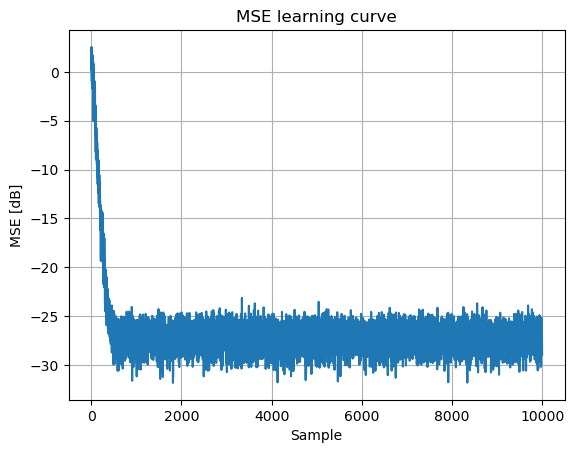

In [4]:
N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
mu = 0.01

# Average the squared error over independent trials
e_avg = np.zeros(N)

for k in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    lms = LMS(M, mu=mu)
    x_vec = np.zeros(M)
    e = np.zeros(N)

    for n in range(N):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]
        e[n] = lms.update(x_vec, d[n])

    e_avg += e**2

print()
MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot the MSE learning curve
lms.plot_MSE(MSE)

# Print the coefficients estimated in the last trial
print(lms.w_)

### Variants of the LMS algorithm <a id="Variants"></a>

#### Normalized Least Mean Squares (NLMS)

The **Normalized Least Mean Squares** (NLMS) algorithm reduces this sensitivity by normalizing the update by the instantaneous energy of the input vector:
$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \frac{\mu e[n]\mathbf{x}_n}{\mathbf{x}_n^\top\mathbf{x}_n+\varepsilon},
$$
where $\varepsilon>0$ is a small regularization constant that prevents division by zero and improves numerical stability. Under ideal assumptions, the normalized step size is bounded by $0<\mu<2$, although smaller values are generally preferred in practical applications.

A class implementation of the NLMS algorithm is similar to that of LMS:

In [5]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class NLMS:

    def __init__(self, M, mu=0.5, eps=1e-6):
        self.M = M
        self.mu = mu
        self.eps = eps
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        input_energy = np.dot(x_vec, x_vec) + self.eps
        grad = e * x_vec   # NLMS gradient
        self.w_ += (self.mu / input_energy) * grad

        return e
    
    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y
        
    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

We can try the NLMS algorithm:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[ 0.99890115 -0.75347281  0.49553876 -0.25226559  0.12082022]


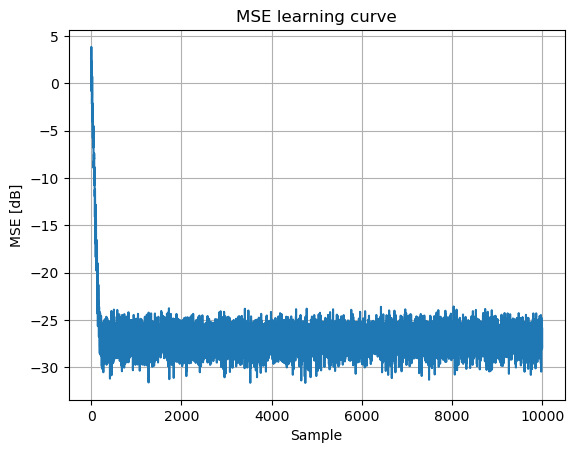

In [6]:
N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
mu = 0.1

# Average the squared error over independent trials
e_avg = np.zeros(N)

for k in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    nlms = NLMS(M, mu=mu)
    x_vec = np.zeros(M)
    e = np.zeros(N)

    for n in range(N):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]
        e[n] = nlms.update(x_vec, d[n])

    e_avg += e**2

print()
MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot the MSE learning curve
nlms.plot_MSE(MSE)

# Print the coefficients estimated in the last trial
print(nlms.w_)

Other LMS variants simplify the coefficient update or introduce additional regularization.

#### Sign-Error LMS

The **Sign-Error LMS** (SELMS): the error is replaced by its sign,
$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu\operatorname{sign}(e[n])\mathbf{x}_n.
$$

In [7]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class SELMS:

    def __init__(self, M, mu=0.01):
        self.M = M
        self.mu = mu
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        grad = np.sign(e) * x_vec   # LMS gradient
        self.w_ += self.mu * grad

        return e
    
    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

#### Sign-Data LMS

The **Sign-Data LMS**, also called **Sign-Regressor LMS** (SDLMS): the input vector is replaced by its element-wise sign,
$$
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu e[n]\operatorname{sign}(\mathbf{x}_n).
$$

In [8]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class SDLMS:

    def __init__(self, M, mu=0.01):
        self.M = M
        self.mu = mu
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        grad = e * np.sign(x_vec)   # LMS gradient
        self.w_ += self.mu * grad

        return e
    
    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

#### Sign-Sign LMS

The **Sign-Sign LMS** (SSLMS): both the error and the input vector are replaced by their signs,
$$
mathbf{w}_{n+1} = \mathbf{w}_n + \mu\operatorname{sign}(e[n])\operatorname{sign}(\mathbf{x}_n).
$$

In [9]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class SSLMS:

    def __init__(self, M, mu=0.01):
        self.M = M
        self.mu = mu
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        grad = np.sign(e) * np.sign(x_vec)   # LMS gradient
        self.w_ += self.mu * grad

        return e
    
    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

#### Leaky LMS

The **Leaky LMS** algorithm adds an $\ell_2$ penalty on the coefficient vector. Its instantaneous cost function can be written as:
$$
\widehat{\mathcal{L}}_n(\mathbf{w}) = \frac{1}{2}e^2[n] + \frac{\alpha}{2}\|\mathbf{w}_n\|_2^2,
$$
where $\alpha\geq 0$ is the leakage factor. The resulting update is:
$$
\mathbf{w}_{n+1} = (1-\mu\alpha)\mathbf{w}_n + \mu e[n]\mathbf{x}_n.
$$

In [10]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class LeakyLMS:

    def __init__(self, M, mu=0.01, alpha=0.001):
        self.M = M
        self.mu = mu
        self.alpha = alpha
        self.w_ = np.zeros(M)

    def update(self, x_vec, d):
        y = np.dot(self.w_, x_vec)
        e = d - y

        self.w_ = ((1 - self.mu * self.alpha) * self.w_
                   + self.mu * e * x_vec)

        return e

    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

We can try the Leaky LMS algorithm:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[ 0.98938968 -0.74328908  0.49465778 -0.24909554  0.1308054 ]


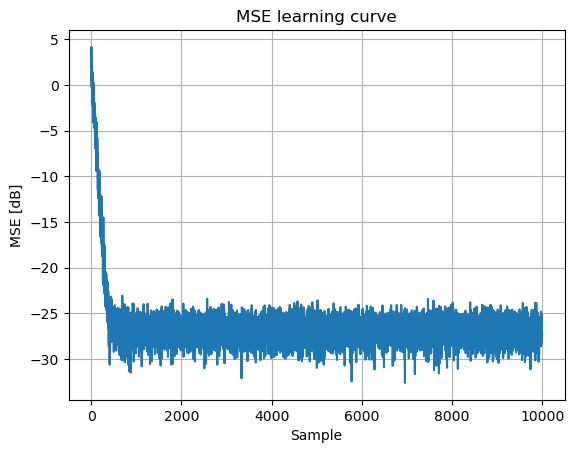

In [11]:
N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
mu = 0.01
alpha = 0.01

# Average the squared error over independent trials
e_avg = np.zeros(N)

for k in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    leaky_lms = LeakyLMS(M, mu=mu, alpha=alpha)
    x_vec = np.zeros(M)
    e = np.zeros(N)

    for n in range(N):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]
        e[n] = leaky_lms.update(x_vec, d[n])

    e_avg += e**2

print()
MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot the MSE learning curve
leaky_lms.plot_MSE(MSE)

# Print the coefficients estimated in the last trial
print(leaky_lms.w_)

## Affine Projection Algorithm <a id="APA"></a>

The **Affine Projection Algorithm** (APA) reuses multiple recent input vectors at each time instant.

Let $K$ denote the projection order\index{Projection order}, and define the input matrix and desired-output vector as:
$$
\mathbf{X}_n
= \left[\mathbf{x}_n,\mathbf{x}_{n-1},\ldots,\mathbf{x}_{n-K+1}\right]
\in\mathbb{R}^{M\times K}
$$
and
$$
\mathbf{d}_n
= \left[d[n],d[n-1],\ldots,d[n-K+1]\right]^\top
\in\mathbb{R}^{K}.
$$
The APA seeks the coefficient vector closest to the current estimate while satisfying the $K$ most recent data constraints:
$$
\min_{\mathbf{w}_{n+1}} \quad \frac{1}{2}\left\|\mathbf{w}_{n+1}-\mathbf{w}_n\right\|_2^2, 
$$
$$
\text{s.t.} \quad  \mathbf{X}_n^\top\mathbf{w}_{n+1}=\mathbf{d}_n.
$$
The \emph{a priori} error vector associated with the current coefficient estimate is:
$$
\mathbf{e}_n = \mathbf{d}_n-\mathbf{X}_n^\top\mathbf{w}_n.
$$
Solving by the method of Lagrange multipliers and introducing a relaxation step size $\mu$ and a regularization parameter $\delta>0$ gives:
$$
\mathbf{w}_{n+1}
= \mathbf{w}_n
+ \mu\mathbf{X}_n
\left(\mathbf{X}_n^\top\mathbf{X}_n+\delta\mathbf{I}\right)^{-1}
\mathbf{e}_n.
$$
For $K=1$, this recursion reduces to the NLMS update.

In [12]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class APA:

    def __init__(self, M, K=4, mu=0.5, delta=1e-3):
        self.M = M
        self.K = K
        self.mu = mu
        self.delta = delta

        self.w_ = np.zeros(M)
        self.X_ = np.zeros((M, K))
        self.d_ = np.zeros(K)

    def update(self, x_vec, d):
        # Update the input and desired-signal buffers
        self.X_ = np.roll(self.X_, shift=1, axis=1)
        self.X_[:, 0] = x_vec

        self.d_ = np.roll(self.d_, shift=1)
        self.d_[0] = d

        # A priori output and error vectors
        y_vec = self.X_.T @ self.w_
        e_vec = self.d_ - y_vec

        # Solve the regularized projection system
        G = self.X_.T @ self.X_
        G += self.delta * np.eye(self.K)
        correction = np.linalg.solve(G, e_vec)

        self.w_ += self.mu * self.X_ @ correction

        return e_vec[0]

    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

We can try the APA algorithm:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[ 0.99641793 -0.74585977  0.49565787 -0.23693157  0.12334413]


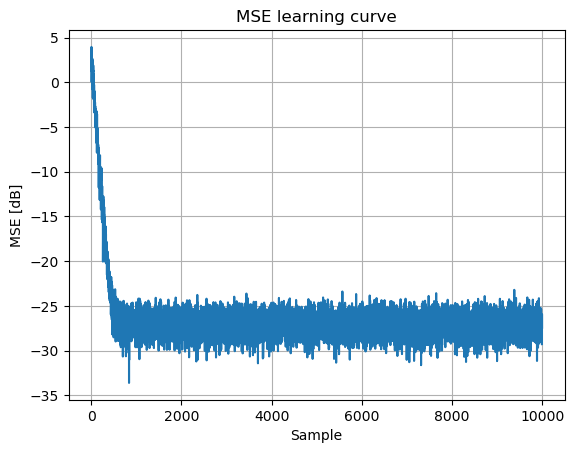

In [13]:
N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
mu = 0.01
K = 4

# Average the squared error over independent trials
e_avg = np.zeros(N)

for k in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    apa = APA(M, mu=mu, K=K)
    x_vec = np.zeros(M)
    e = np.zeros(N)

    for n in range(N):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]
        e[n] = apa.update(x_vec, d[n])

    e_avg += e**2

print()
MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot the MSE learning curve
apa.plot_MSE(MSE)

# Print the coefficients estimated in the last trial
print(apa.w_)

## Recursive Least Squares <a id="RLS"></a>

The **Recursive Least Squares\** (RLS) algorithm is an adaptive filtering method characterized by rapid convergence. Unlike LMS, which uses only the current squared error, RLS minimizes an exponentially weighted sum of past squared errors:
$$
\mathcal{L}_n(\mathbf{w}) = \sum_{i=1}^{n}\lambda^{n-i} \left(d[i]-\mathbf{w}_n^\top \mathbf{x}_i\right)^2,
$$
where $\lambda$ is the forgetting factor\index{Forgetting factor}, with $0<\lambda\leq 1$. Values close to one assign substantial weight to older observations, whereas smaller values improve tracking of time-varying systems but increase estimation variability.

At time $n$, the RLS recursion consists of the following steps:
1. Compute the *a priori* output and prediction error using the previous coefficient estimate:
    $$
    y[n]=\mathbf{w}_{n-1}^\top\mathbf{x}_n, \qquad e[n]=d[n]-y[n].
    $$
2. Compute the **gain vector**:
    $$
    \mathbf{k}_n = \frac{\mathbf{P}_{n-1}\mathbf{x}_n}{\lambda+\mathbf{x}_n^\top\mathbf{P}_{n-1}\mathbf{x}_n}.
    $$
3. Update the **coefficient estimate**:
    $$
    \mathbf{w}_n = \mathbf{w}_{n-1}+\mathbf{k}_n e[n].
    $$
4. Update the **inverse correlation matrix**:
    $$
    \mathbf{P}_n = \frac{1}{\lambda} \left(\mathbf{P}_{n-1} - \mathbf{k}_n\mathbf{x}_n^\top\mathbf{P}_{n-1}\right).
$$
The matrix is commonly initialized as $\mathbf{P}_0=\delta^{-1}\mathbf{I}$, where $\delta>0$ controls the uncertainty associated with the initial coefficient vector. A small value of $\delta$ corresponds to a large initial covariance and therefore permits large early updates.

In [14]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt


class RLS:

    def __init__(self, M, lam=0.99, delta=1.0):
        self.M = M
        self.lam = lam
        self.delta = delta

        self.w_ = np.zeros(M)
        self.P_ = (1.0 / delta) * np.eye(M)

    def update(self, x_vec, d):
        x_vec = np.asarray(x_vec).reshape(-1)

        # A priori output and error
        y = self.w_ @ x_vec
        e = d - y

        # Gain vector
        Px = self.P_ @ x_vec
        denominator = self.lam + x_vec @ Px
        k = Px / denominator

        # Coefficient and inverse-correlation updates
        self.w_ += k * e
        self.P_ = (self.P_ - np.outer(k, Px)) / self.lam

        return e

    def predict(self, x):
        y = sp.lfilter(self.w_, [1.0], x)
        
        return y

    def plot_MSE(self, MSE):
        plt.figure()
        plt.plot(MSE)
        plt.grid()
        plt.title("MSE learning curve")
        plt.xlabel("Sample")
        plt.ylabel("MSE [dB]")

We can try the RLS algorithm:

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
[ 0.99899773 -0.75024612  0.50041953 -0.25014213  0.12459666]


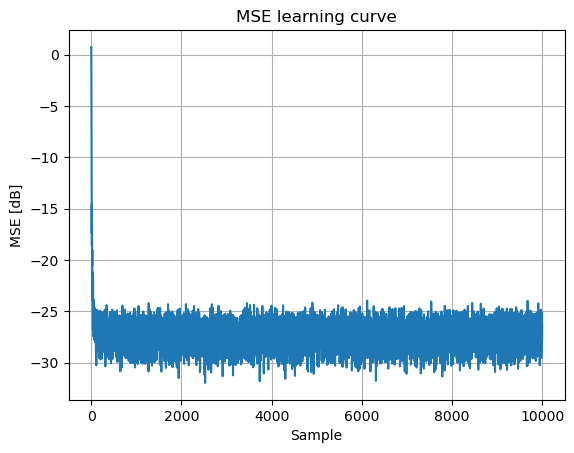

In [15]:
N = 10000
N_avg = 30
SNR_dB = 30
w0 = np.array([1.0000, -0.7500, 0.5000, -0.2500, 0.1250])
M = len(w0)
lam = 0.999

# Average the squared error over independent trials
e_avg = np.zeros(N)

for k in range(N_avg):
    print(">", end="")

    x = np.random.randn(N)
    r = sp.lfilter(w0, [1.0], x)

    signal_power = np.mean(r**2)
    noise_power = signal_power / (10**(SNR_dB / 10))
    v = np.sqrt(noise_power) * np.random.randn(N)
    d = r + v

    rls = RLS(M, lam=lam)
    x_vec = np.zeros(M)
    e = np.zeros(N)

    for n in range(N):
        x_vec[1:] = x_vec[:-1]
        x_vec[0] = x[n]
        e[n] = rls.update(x_vec, d[n])

    e_avg += e**2

print()
MSE = 10 * np.log10(e_avg / N_avg + np.finfo(float).eps)

# Plot the MSE learning curve
rls.plot_MSE(MSE)

# Print the coefficients estimated in the last trial
print(rls.w_)